# Diabetes Prediction - KNN

This notebook follows a simple ML workflow:

1. Load and inspect data
2. Clean missing values
3. Do EDA with graphs
4. Split into train and test data
5. Build a preprocessing + KNN pipeline
6. Tune hyperparameters with cross-validation
7. Evaluate using ROC-AUC and classification metrics

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 2. Load Dataset

In [2]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.shape

(768, 9)

In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 3. Treat Zero Values as Missing

In [5]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[zero_cols] = df[zero_cols].replace(0, np.nan)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 4. EDA Analysis with Visualizations

In [7]:
df["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


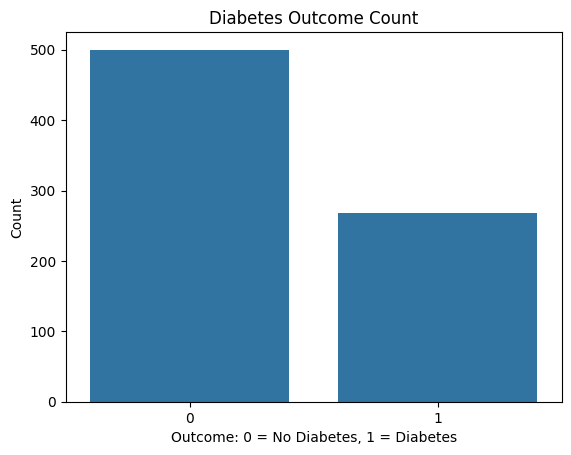

In [8]:
sns.countplot(data=df, x="Outcome")
plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome: 0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Count")
plt.show()

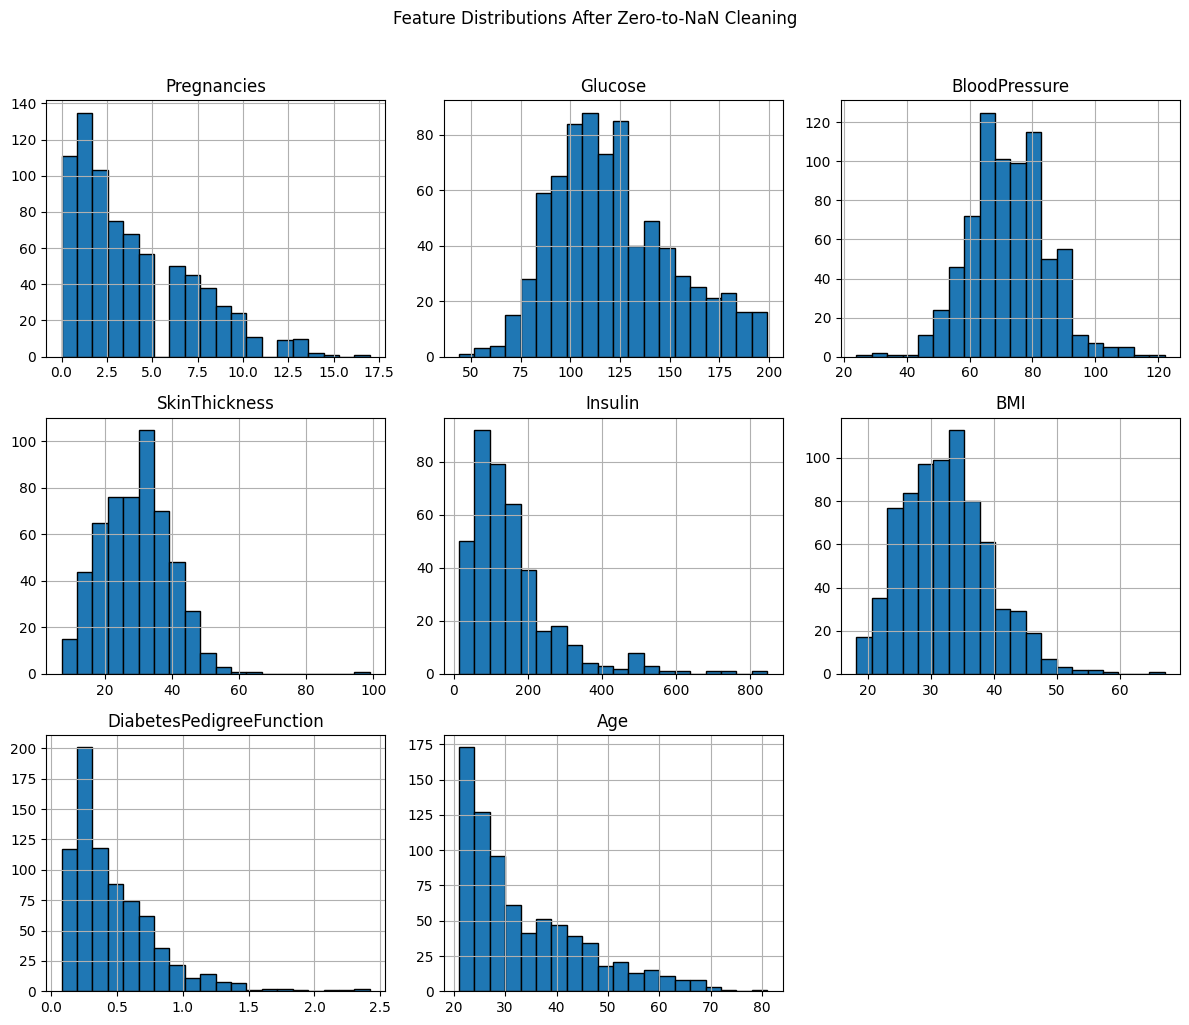

In [9]:
df.drop(columns="Outcome").hist(figsize=(12, 10), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions After Zero-to-NaN Cleaning", y=1.02)
plt.tight_layout()
plt.show()

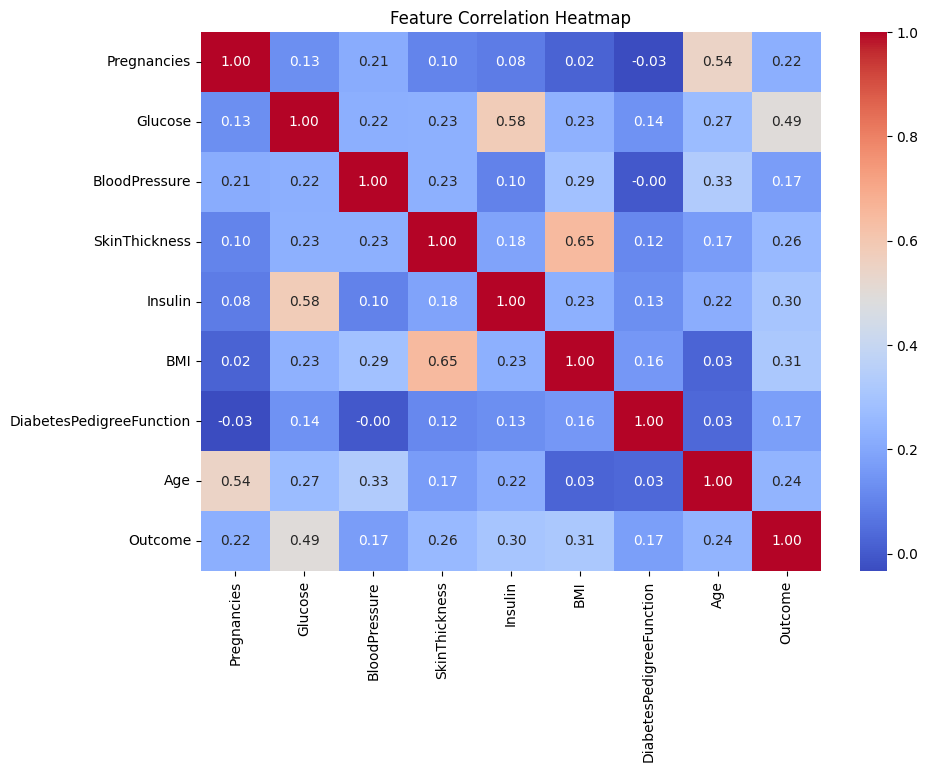

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

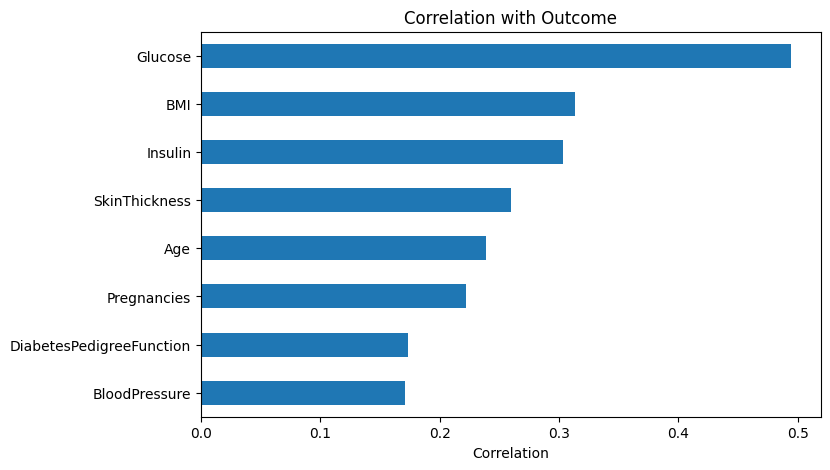

In [11]:
df.corr(numeric_only=True)["Outcome"].drop("Outcome").sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Correlation with Outcome")
plt.xlabel("Correlation")
plt.show()

## 5. Create X and y

In [13]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [14]:
y.value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


## 6. Train Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train.shape, X_test.shape

((614, 8), (154, 8))

## 7. Build KNN Model

In [16]:
knn_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ]
)

knn_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

## 8. Tune and Train

In [17]:
search_space = {
    "knn__n_neighbors": np.arange(1, 32, 2),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

model = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=search_space,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]),
                         'knn__weights': ['uniform', 'distance']},
             scoring='roc_auc')

In [18]:
model.best_params_

{'knn__metric': 'euclidean',
 'knn__n_neighbors': np.int64(17),
 'knn__weights': 'uniform'}

In [19]:
model.best_score_

np.float64(0.8305329457364341)

## 9. Evaluate Test Data

In [20]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

pd.DataFrame(
    {
        "Metric": ["Accuracy", "ROC-AUC"],
        "Score": [test_accuracy, test_roc_auc],
    }
)

,Metric,Score
0,Accuracy,0.746753
1,ROC-AUC,0.803889


In [21]:
confusion_matrix(y_test, y_pred)

array([[85, 15],
       [24, 30]])

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



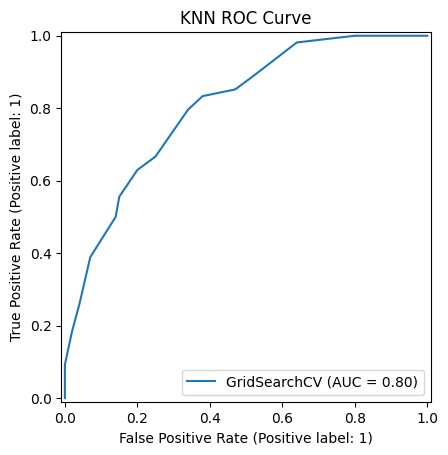

In [23]:
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("KNN ROC Curve")
plt.show()

## 10. Predict New Patient

In [24]:
new_patient = pd.DataFrame(
    {
        "Pregnancies": [2],
        "Glucose": [120],
        "BloodPressure": [70],
        "SkinThickness": [25],
        "Insulin": [80],
        "BMI": [28.5],
        "DiabetesPedigreeFunction": [0.45],
        "Age": [32],
    }
)

model.predict(new_patient)

array([0])

In [25]:
model.predict_proba(new_patient)[:, 1]

array([0.23529412])